In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [14]:
class BatsmanState(TypedDict):
    runs: int
    balls_faced: int
    fours: int
    sixes: int
    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float
    summary: str

In [15]:
def calculate_sr(state: BatsmanState):
    strike_rate = (state["runs"] / state["balls_faced"]) * 100
    return {"strike_rate": strike_rate}

In [16]:
def calculate_bpb(state: BatsmanState):
    balls_per_boundary = state["balls_faced"] / (state["fours"] + state["sixes"])
    return {"balls_per_boundary": balls_per_boundary}

In [17]:
def calculate_bp(state: BatsmanState):
    boundary_percent = ((state["fours"] * 4 + state["sixes"] * 6) / state["runs"]) * 100
    return {"boundary_percent": boundary_percent}

In [23]:
def get_summary(state: BatsmanState):
    summary = f"""Strike Rate: {state['strike_rate']}\n
        Balls per Boundary: {state['balls_per_boundary']}\n
        Boundary Percentage: {state['boundary_percent']}
    """
    return {"summary": summary}

In [24]:
# Create a graph
graph = StateGraph(BatsmanState)

# Add nodes
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_bp", calculate_bp)
graph.add_node("get_summary", get_summary)

# Add edges
graph.add_edge(START, "calculate_sr")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_bp")
graph.add_edge("calculate_sr", "get_summary")
graph.add_edge("calculate_bpb", "get_summary")
graph.add_edge("calculate_bp", "get_summary")
graph.add_edge("get_summary", END)

workflow = graph.compile()

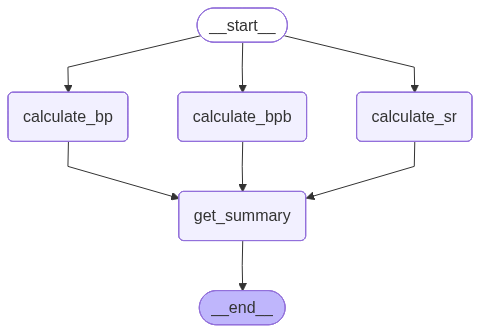

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [27]:
initial_state = {
    "runs": 100,
    "balls_faced": 50,
    "fours": 6,
    "sixes": 4
}

final_state = workflow.invoke(initial_state)
final_state

{'runs': 100,
 'balls_faced': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'balls_per_boundary': 5.0,
 'boundary_percent': 48.0,
 'summary': 'Strike Rate: 200.0\n\n        Balls per Boundary: 5.0\n\n        Boundary Percentage: 48.0\n    '}